['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


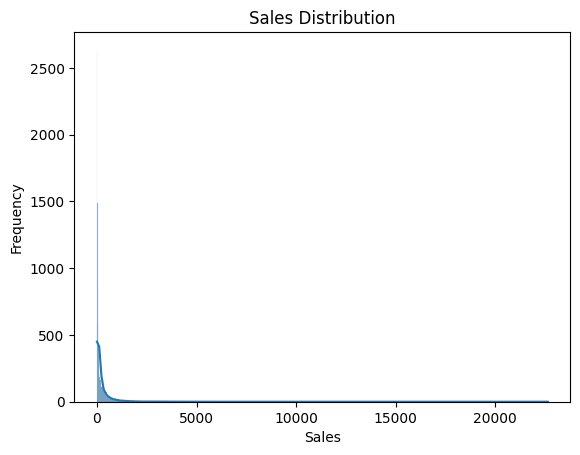

Skewness: 12.97275234181623
Mean: 229.85800083049833
Median: 54.489999999999995


In [19]:
# Task 1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("lab3.csv", encoding="latin1")

print(df.columns.tolist())

sales = df["Sales"].dropna()

# Histogram + KDE
sns.histplot(sales, kde=True)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()

# Skewness, mean, median
print("Skewness:", sales.skew())
print("Mean:", sales.mean())
print("Median:", sales.median())

# mean and median are apart meaning there are alot of outliers
# it is skewed to right side and mean is not right to show the data


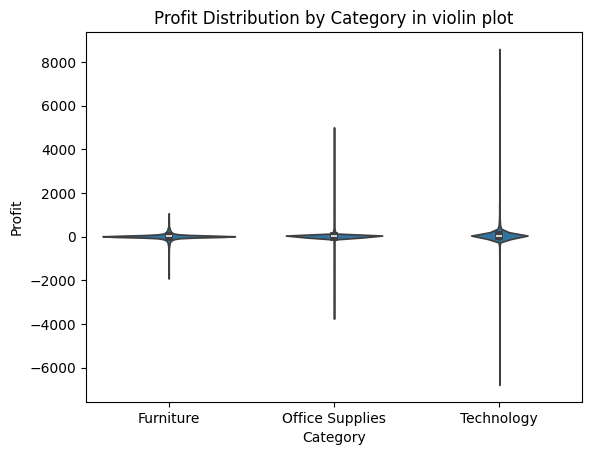

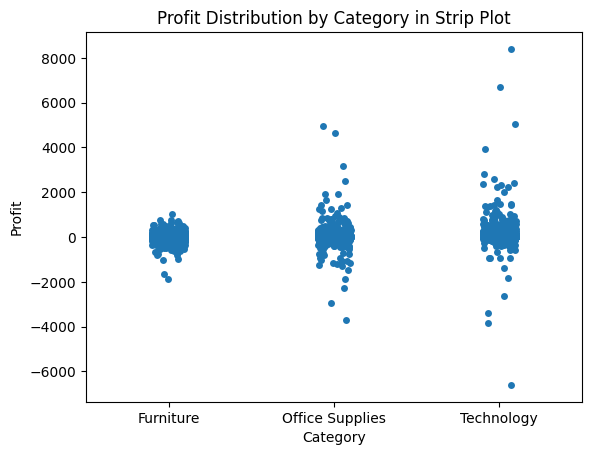

In [23]:
# Task 2

# profit by category (violin plot)
sns.violinplot(data=df, x="Category", y="Profit")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit Distribution by Category in violin plot")
plt.show()

# profit by category (strip plot)
sns.stripplot(data=df, x="Category", y="Profit", jitter=True)
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit Distribution by Category in Strip Plot")
plt.show()
# Violin plot is better as shows unusual spread values using density and shape of the data categorically.
# Strip plot shows singular values clearly but they overlap and hide the underlying info

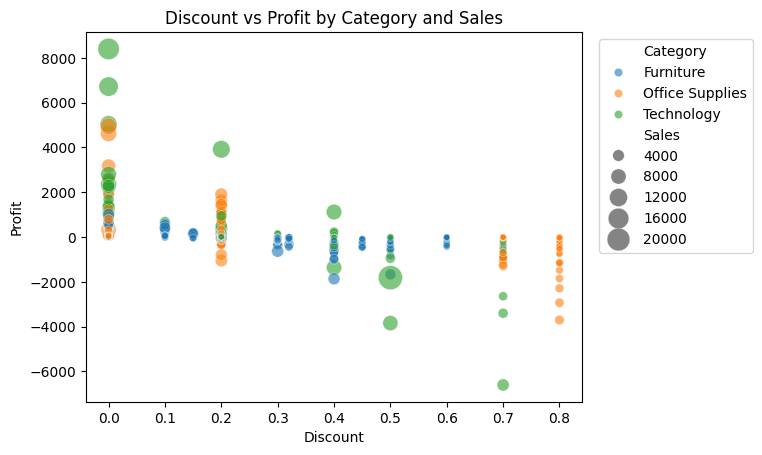

In [28]:
# Task 3
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    size="Sales",
    sizes=(20, 300),
    alpha=0.6
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit by Category and Sales")
plt.show()

# pattern visible is that Technology has largest sales and widest profit range
# and it has very less loss at high discount values


Pearson Correlation Matrix:
             Row ID  Postal Code  Sales  Quantity  Discount  Profit
Row ID        1.000        0.010 -0.001    -0.004     0.013   0.012
Postal Code   0.010        1.000 -0.024     0.013     0.058  -0.030
Sales        -0.001       -0.024  1.000     0.201    -0.028   0.479
Quantity     -0.004        0.013  0.201     1.000     0.009   0.066
Discount      0.013        0.058 -0.028     0.009     1.000  -0.219
Profit        0.012       -0.030  0.479     0.066    -0.219   1.000





Spearman Correlation Matrix:
             Row ID  Postal Code  Sales  Quantity  Discount  Profit
Row ID        1.000        0.011 -0.001    -0.002     0.013  -0.011
Postal Code   0.011        1.000 -0.002     0.014     0.053  -0.005
Sales        -0.001       -0.002  1.000     0.327    -0.057   0.518
Quantity     -0.002        0.014  0.327     1.000    -0.001   0.234
Discount      0.013        0.053 -0.057    -0.001     1.000  -0.543
Profit       -0.011       -0.005  0.518     0.234    -

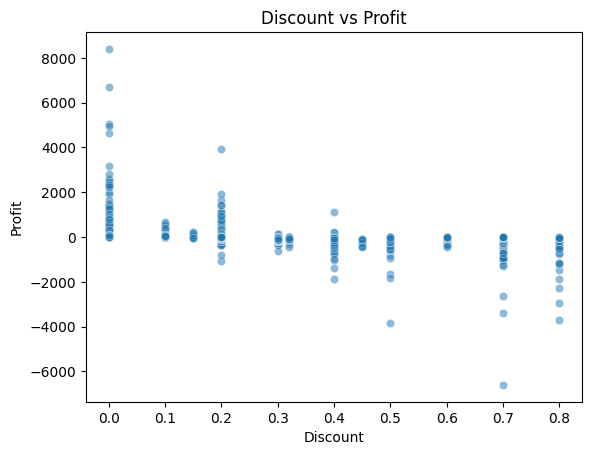

In [32]:
# Task 4

# selecting numerical cols
numeric_df = df.select_dtypes(include="number")

# pearson corr matrix
pearson_corr = numeric_df.corr(method="pearson")

print("Pearson Correlation Matrix:")
print(pearson_corr.round(3))

print("\n\n\n\n")

# spearman correlation matrix
spearman_corr = numeric_df.corr(method="spearman")

print("Spearman Correlation Matrix:")
print(spearman_corr.round(3))

# Find the pair with the largest difference
difference = abs(pearson_corr - spearman_corr)

# Ignore the diagonal
difference.values[range(len(difference)), range(len(difference))] = 0

print("\nDifference between Pearson and Spearman:")
print(difference.round(3))

# Get the pair with the largest difference
pair = difference.stack().idxmax()

print("\nPair with largest disagreement:", pair)
print("Pearson:", pearson_corr.loc[pair[0], pair[1]])
print("Spearman:", spearman_corr.loc[pair[0], pair[1]])

# Scatter plot of the selected pair
x = pair[0]
y = pair[1]

sns.scatterplot(data=df, x=x, y=y, alpha=0.5)

plt.xlabel(x)
plt.ylabel(y)
plt.title(f"{x} vs {y}")
plt.show()

# Pearson (-0.219) and Spearman (-0.543) differ for Discount vs Profit due to outliers and a non linear pattern.
# Correlation does not show that causation higher discounts do not necessarily cause lower profit.

Region × Category Sales:
Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


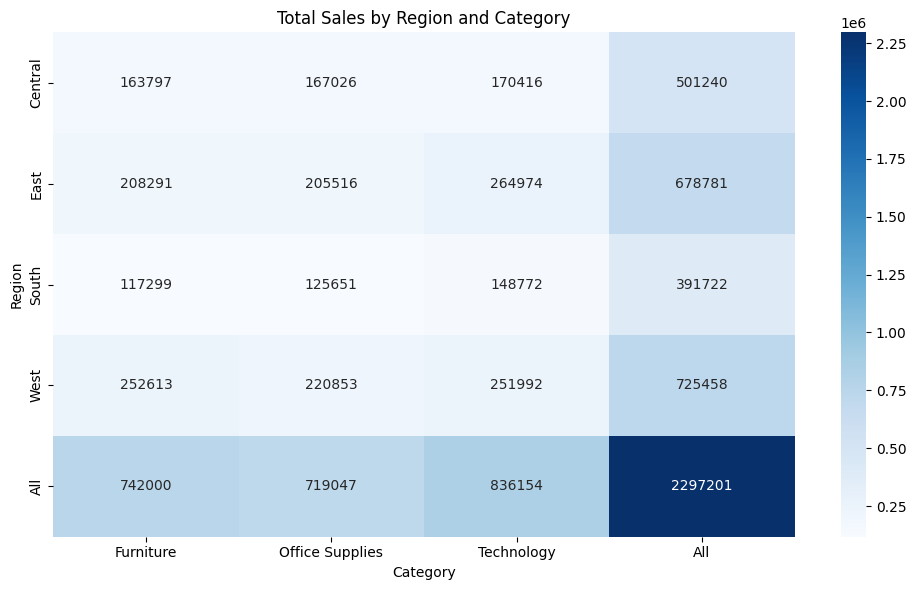


Highest Revenue Combination: East Tech combination contributes most to overall revenue, total sales near 264,974.
Region: East
Category: Technology
Total Sales: 264973.981


In [36]:
# Task 5
# Region × Category total sales
sales_pivot = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    margins=True
)

print("Region × Category Sales:")
print(sales_pivot)

# Heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    sales_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Total Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# Find the region category combination with highest sales
region_category = sales_pivot.drop(index="All").drop(columns="All")

max_region, max_category = region_category.stack().idxmax()
max_sales = region_category.loc[max_region, max_category]

print("\nHighest Revenue Combination: East Tech combination contributes most to overall revenue, total sales near 264,974.")
print("Region:", max_region)
print("Category:", max_category)
print("Total Sales:", max_sales)

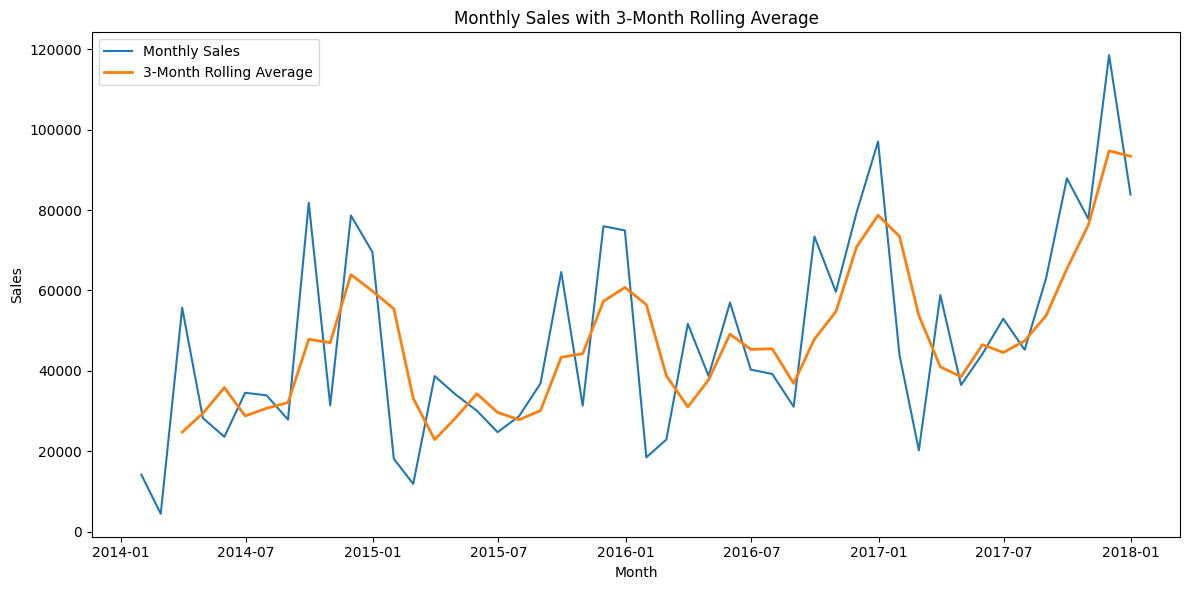

In [44]:
# Task 6
df = pd.read_csv("lab3.csv", encoding="latin1")
# converting order date to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Set date as index
df = df.set_index("Order Date")

# Monthly total sales
monthly = df["Sales"].resample("ME").sum()

# 3 month rolling average
rolling = monthly.rolling(window=3).mean()

# Plot both
plt.figure(figsize=(12, 6))

plt.plot(monthly, label="Monthly Sales")
plt.plot(rolling, label="3 Month Rolling Average", linewidth=2)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales with 3 Month Rolling Average")
plt.legend()
plt.tight_layout()
plt.show()

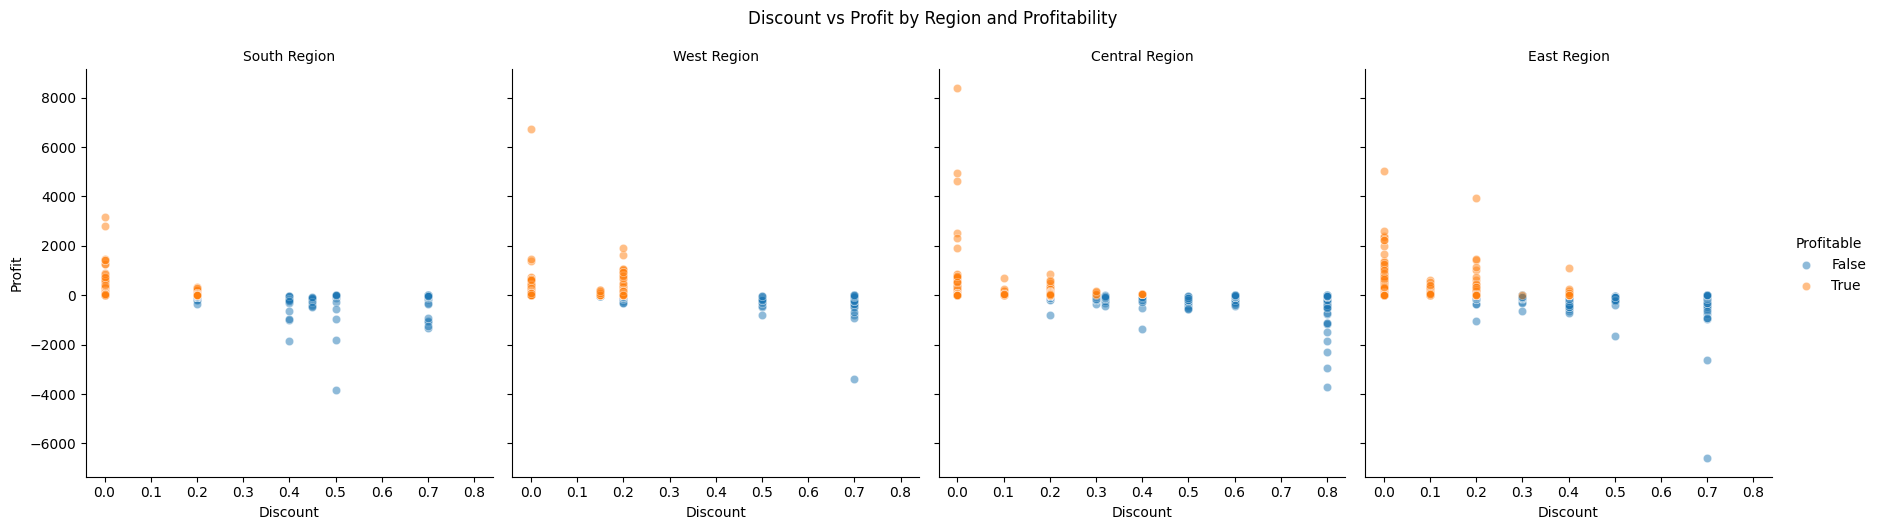

In [48]:
# Task 7

# create profit status
df["Profitable"] = df["Profit"] > 0

# Faceted scatter plot
g = sns.FacetGrid(
    df,
    col="Region",
    hue="Profitable",
    height=5,
    aspect=0.9
)

g.map_dataframe(
    sns.scatterplot,
    x="Discount",
    y="Profit",
    alpha=0.5
)

g.add_legend()
g.set_axis_labels("Discount", "Profit")
g.set_titles("{col_name} Region")
g.fig.suptitle("Discount vs Profit by Region and Profitability", y=1.05)

plt.show()

# central region differs the most


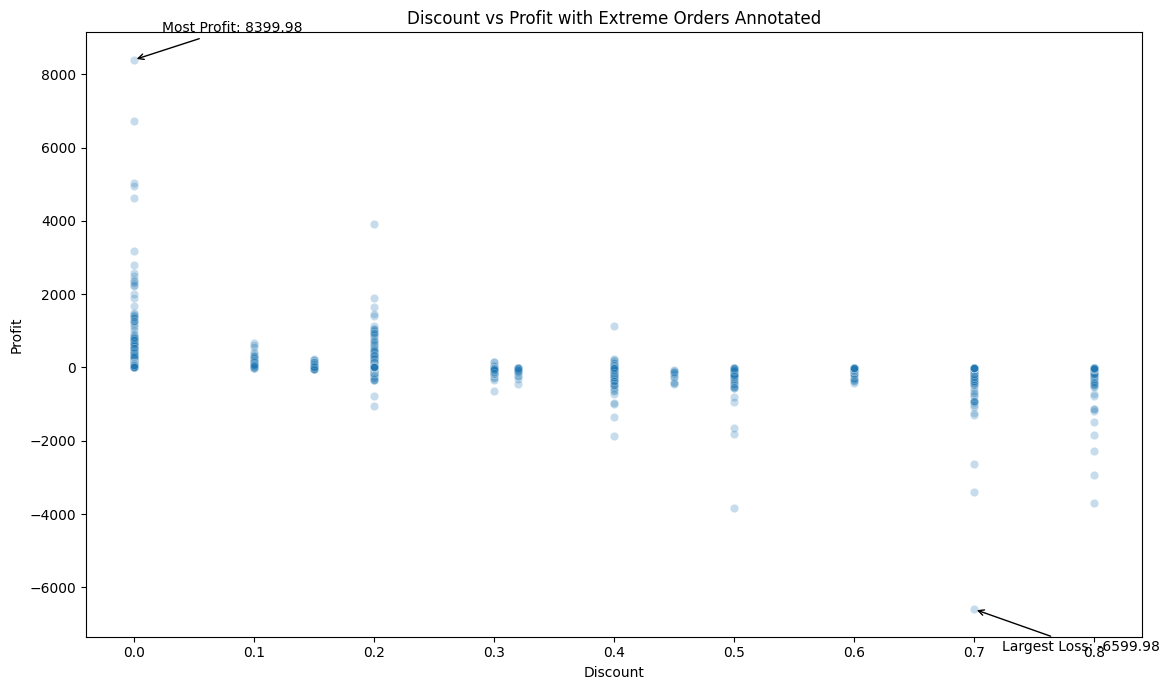

Most Profitable Order:
Row ID                                            6827
Order ID                                CA-2016-118689
Order Date                                   10/2/2016
Ship Date                                    10/9/2016
Ship Mode                               Standard Class
Customer ID                                   TC-20980
Customer Name                             Tamara Chand
Segment                                      Corporate
Country                                  United States
City                                         Lafayette
State                                          Indiana
Postal Code                                      47905
Region                                         Central
Product ID                             TEC-CO-10004722
Category                                    Technology
Sub-Category                                   Copiers
Product Name     Canon imageCLASS 2200 Advanced Copier
Sales                                     

In [50]:
# Task 8
df = pd.read_csv("lab3.csv", encoding="latin1")

# Find the most profitable order and the largest loss
max_profit = df.loc[df["Profit"].idxmax()]
max_loss = df.loc[df["Profit"].idxmin()]

# Fixed scatter plot using alpha
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.25
)

# Annotate most profitable order
plt.annotate(
    f"Most Profit: {max_profit['Profit']:.2f}",
    xy=(max_profit["Discount"], max_profit["Profit"]),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Annotate largest loss
plt.annotate(
    f"Largest Loss: {max_loss['Profit']:.2f}",
    xy=(max_loss["Discount"], max_loss["Profit"]),
    xytext=(20, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit with Extreme Orders Annotated")
plt.tight_layout()
plt.show()

# Print the orders for reference
print("Most Profitable Order:")
print(max_profit)

print("\nLargest Loss:")
print(max_loss)

# Alpha used as transparency helps see overlapping values and lower opacity makes dense areas visible and keeps observations preserved.